In [1]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import json
import os
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
import re
import math
import ollama
torch.manual_seed(1234)
img2description = dict()

SYSTEM_PROMPT = (
    "A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant "
    "first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning "
    "process and answer are enclosed within <think> </think> and <answer> </answer> tags, respectively, i.e., "
    "<think> reasoning process here </think><answer> answer here </answer>"
)


def prepare_inputs(img_path, instruction):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img_path},
                {"type": "text", "text": f"Output the bounding box in the image corresponding to the instruction: {instruction}. Output the thinking process in <think> </think> and your grouding box. Following \"<think> thinking process </think>\n<answer>(x1,y1),(x2,y2)</answer>)\" format."}
            ]
        }
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt",
    )
    return inputs.to("cuda")

model_name="deepseek-r1:7b" 
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Zery/Qwen2-VL-7B_visual_rft_lisa_IoU_reward", device_map="auto"
).eval()

processor = AutoProcessor.from_pretrained("Zery/Qwen2-VL-7B_visual_rft_lisa_IoU_reward")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [ ]:

image_path = "../assets/test1.jpg"
input_text="what are the child in red shirt and child in green shirt doing?"
prompt = (
    "A conversation between User and Assistant. The user asks a question, and the Assistant find all the noun chunks in it. The chunk is like a noun phrase, e.g., the chunk in sentence:'what is the child in green doing?' is 'the child in green'. "
    "answer are enclosed within <answer> </answer> tags, respectively, i.e., "
    "find all matching noun chunks in the sentence. "
    "<answer> answer here </answer>"
    "if there is more than one answer, separate them with a new <answer> tag."
    "the user asks:{}"
).format(input_text)

response_ol = ollama.chat(model=model_name, messages=[{"role": "user", "content": prompt}])
response_ol = response_ol.message.content

# use regex to extract the <answer> tags from the response
infos=[]
matches_ol = re.findall(r'<answer>(.*?)</answer>', response_ol)
print(matches_ol)
for chunk in matches_ol:
    inputs = prepare_inputs(image_path, "{}. Output thinking process as detail as possibile".format(chunk))
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=128)
    response = processor.batch_decode(
        generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    print(response)
    think_pattern = r"<think>(.*?)</think>"
    think_matches = re.findall(think_pattern, response, re.DOTALL)
    think_text = think_matches[-1].strip() if think_matches else "No think process found"
    pattern = r"\(\s*(\d+)\s*,\s*(\d+)\s*\)\s*,\s*\(\s*(\d+)\s*,\s*(\d+)\s*\)"
    matches = re.findall(pattern, response)
    x1, y1, x2, y2 = map(int, matches[0])
    infos.append((chunk, (x1, y1, x2, y2),think_text))

['the child in red shirt', 'the child in green shirt']
system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning process and answer are enclosed within <think> </think> and <answer> </answer> tags, respectively, i.e., <think> reasoning process here </think><answer> answer here </answer>
user
Output the bounding box in the image corresponding to the instruction: the child in red shirt. Output thinking process as detail as possibile. Output the thinking process in <think> </think> and your grouding box. Following "<think> thinking process </think>
<answer>(x1,y1),(x2,y2)</answer>)" format.
assistant
<think> The child in red shirt is the one wearing the red jersey. </think>
<answer>(666,156),(933,888)</answer>
system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The as

[('the child in red shirt', (666, 156, 933, 888), 'The child in red shirt is the one wearing the red jersey.'), ('the child in green shirt', (110, 50, 320, 848), 'The child in green shirt is the one who is not wearing an orange shirt.')]
The child in green shirt is the one who is not wearing an orange shirt.
The child in green shirt is the one who is not wearing an orange shirt.


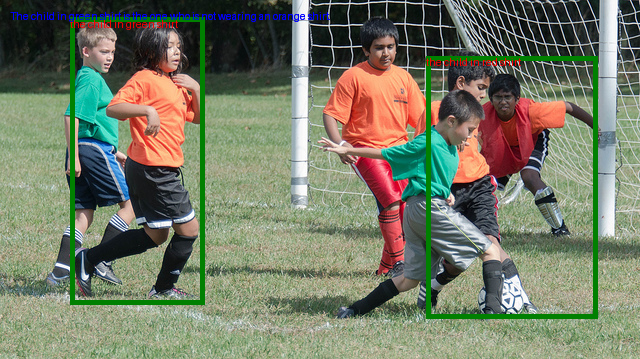

In [3]:
# think_pattern = r"<think>(.*?)</think>"
# think_matches = re.findall(think_pattern, response, re.DOTALL)
# think_text = think_matches[-1].strip() if think_matches else "No think process found"
# pattern = r"\(\s*(\d+)\s*,\s*(\d+)\s*\)\s*,\s*\(\s*(\d+)\s*,\s*(\d+)\s*\)"
# matches = re.findall(pattern, response)
print(infos)
image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)
w, h = Image.open(image_path).size
for info in infos:
    chunk, matches, think = info
    # image = Image.open(image_path).convert("RGB")
    # draw = ImageDraw.Draw(image)
    # w, h = Image.open(image_path).size
    x1, y1, x2, y2 = map(int, matches)
    box_r1 = [int(x1) / 1000, int(y1) / 1000, int(x2) / 1000, int(y2) / 1000]
    draw = ImageDraw.Draw(image)
    draw.rectangle([box_r1[0] * w, box_r1[1] * h, box_r1[2] * w, box_r1[3] * h], outline="green", width=5)
    font=ImageFont.load_default()
    print(think_text)
    draw.text((box_r1[0] * w, box_r1[1] * h), chunk, font=font, fill="red")
    draw.text((10,10), think_text, font=font, fill="blue")
image